## **Spatial GNN-Based Stop Quality Classification for Nairobi’s Transport Network**

### Introduction

Graph Neural Networks (GNNs) are a family of deep learning models designed to work with **graph-structured data**, where entities (nodes) are connected through relationships (edges).
They extend traditional neural networks by allowing information to flow between neighboring nodes, making them ideal for problems where **structure, proximity, and connectivity** matter—such as transport networks.

There are several major types of GNN architectures:

* **GCN (Graph Convolutional Network)**
  Performs convolution-like neighborhood aggregation. Simple, fast, and highly effective for node classification.

* **GraphSAGE (Sampling and Aggregation Networks)**
  Learns how to sample and aggregate neighbors, suitable for large or inductive graphs.

* **GAT (Graph Attention Network)**
  Uses attention mechanisms to learn which neighbors matter more, allowing weighted, adaptive message passing.

* **GIN (Graph Isomorphism Network)**
  Very expressive; captures subtle structural differences and is often used in chemistry and molecular graphs.

* **MPNN (Message Passing Neural Network)**
  A general framework where nodes exchange learned messages; many architectures fall under this umbrella.

This notebook applies a GNN-based approach to evaluate and predict the quality of public transport stops across Nairobi.
Public transit systems are inherently **spatial and interconnected**, making GNNs a natural fit.
Later in the notebook, we will explain **why the GCN variant is chosen specifically** for this task.

The goal is to combine **engineered stop features** with **spatial relationships** to quantify stop quality, identify high-impact candidate locations, and support future route-level planning.

Traditional ML models treat each stop independently, but transport infrastructure is inherently **spatial and interconnected**. The performance of one stop influences and is influenced by nearby stops, road networks, and population density.

To capture these spatial dependencies, we convert all stops into a **graph**, where nodes represent stop locations and edges connect geographically close stops.
Using this structure, the GNN learns both:

* **Node-level features** (population, accessibility, congestion, etc.)
* **Graph structure** (spatial proximity and neighborhood patterns)

A data-driven label **`is_good_stop`** is generated from service, accessibility, and equity metrics, enabling supervised learning. The trained model is then used to:

* Evaluate existing stops
* Predict high-quality candidate stops
* Identify underserved areas with the highest potential impact
* Generate spatial insights for transport planning

### Objectives

1. **Construct a spatial graph of Nairobi’s transport stops** using geographic proximity and engineered features.

2. **Train a Graph Convolutional Network (GCN)** to classify stops as good or bad based on service quality, accessibility, demand, and equity indicators.

3. **Evaluate the model’s performance** on a held-out test set and verify generalization using classification metrics and visual diagnostics.

4. **Generate predicted stop quality scores** for all stops and identify high-potential candidate locations for network improvement.

### i. Libraries
This cell loads all necessary libraries for:

- **Data manipulation**: pandas, numpy  
- **Visualization**: matplotlib, seaborn  
- **Deep Learning (PyTorch)**: core tensor operations, neural network layers  
- **Graph Neural Networks**: PyTorch Geometric's `Data` class and `GCNConv`  
- **Preprocessing & Evaluation**: scalers, encoders, train/test split, model metrics  
- **Spatial Operations**: `cKDTree` for nearest-neighbour queries  
- **Utility**: suppressing warnings and setting computation device (CPU/GPU)

In [1]:
# Cell 1: Imports
import pandas as pd # Core data manipulation
import numpy as np # Core data manipulation
import matplotlib.pyplot as plt # Visualization
import seaborn as sns # Visualization
import torch # PyTorch for tensors and neural nets
import torch.nn.functional as F # PyTorch for tensors and neural nets
from torch_geometric.data import Data # PyTorch Geometric for graph data structures & GNN layers
from torch_geometric.nn import GCNConv # PyTorch Geometric for graph data structures & GNN layers
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler# Preprocessing utilities
from sklearn.model_selection import train_test_split # Preprocessing utilities
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve # Performance metrics
from scipy.spatial import cKDTree # Spatial indexing (nearest neighbors)
import warnings
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# Automatically select GPU (CUDA) if available, else fallback to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### ii. Load Training or Test Dataset

This cell loads the dataset used for model training or evaluation.  
Two file paths are provided:

- **Training dataset:** `stop_features_training_data.csv`
- **Cleaned test dataset:** `stop_features_test_cleaned.csv`

Uncomment the one you want to use.

In [2]:
# Load the main training dataset
df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_training_data.csv')

# Alternative option:
# Load the cleaned test dataset instead (uncomment if needed)
# df = pd.read_csv('/home/dataopske/Desktop/jav/data/training_data/stop_features_test_cleaned.csv')


In [3]:
df.isnull().sum()

stop_id                          0
lat                              0
lon                              0
ward                             0
is_existing_stop                 0
nearest_node_degree              0
road_type                        0
distance_to_major_road           0
distance_to_nearest_stop         0
stops_within_500m                0
stops_within_1km                 0
pop_not_served_nearby            0
poverty_rate_weighted_pop        0
route_count_serving              0
trips_per_day                    0
avg_headway_minutes           3961
service_span_hours               0
routes_within_500m               0
avg_speed_daily                  0
avg_speed_peak                   0
avg_speed_offpeak                0
congestion_pct_daily             0
congestion_pct_peak              0
trip_count_daily                 0
trip_count_peak                  0
demand_variability_cv            0
dominant_congestion_level        0
ward_pct_access                  0
ward_population     

From the results:
- Most columns have **0 missing values**
- `avg_headway_minutes` has **3961 missing values**
- `ward_category` has **104 missing values**

In [4]:
# Print the dimensions of the dataset (rows, columns)
print(f"Shape: {df.shape}")

# Show distribution of the target variable (class balance check)
print(f"\nTarget distribution:\n{df['is_good_stop'].value_counts()}")

# Display only columns that have missing values
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


Shape: (8234, 40)

Target distribution:
is_good_stop
0    6325
1    1909
Name: count, dtype: int64

Missing values:
avg_headway_minutes    3961
ward_category           104
dtype: int64


1. **Dataset Shape**  
   Shows the number of rows and columns.  
   - Current shape: **8,234 rows × 40 columns**

2. **Target Variable Distribution (`is_good_stop`)**  
   Helps evaluate class balance for modeling.  
   - Class 0: 6,325 samples  
   - Class 1: 1,909 samples  
   → The dataset is moderately imbalanced (ratio ~3.3:1)

3. **Columns With Missing Values**  
   Displays only columns where missing values exist.  
   - `avg_headway_minutes`: 3,961 missing  
   - `ward_category`: 104 missing  


### iii. Handle Missing Values

This cell performs missing value imputation for both numerical and categorical
features:

**Numerical Columns**
- Columns are listed in `num_cols`.
- For any numerical feature with missing values, we apply **median imputation**.
- Median is preferred because it is robust to outliers and skewed distributions.

**Categorical Columns**
- Columns are listed in `cat_cols`.
- Missing values are filled using the **most frequent category (mode)**.
- This preserves the category structure without introducing new labels.

In [5]:
num_cols = [
    'nearest_node_degree', 'distance_to_major_road', 'distance_to_nearest_stop',
    'stops_within_500m', 'stops_within_1km', 'pop_not_served_nearby',
    'poverty_rate_weighted_pop', 'route_count_serving', 'trips_per_day',
    'avg_headway_minutes', 'service_span_hours', 'routes_within_500m',
    'avg_speed_daily', 'avg_speed_peak', 'avg_speed_offpeak',
    'congestion_pct_daily', 'congestion_pct_peak', 'trip_count_daily',
    'trip_count_peak', 'demand_variability_cv', 'ward_pct_access',
    'ward_population', 'ward_poverty_rate', 'distance_to_cbd',
    'coverage_efficiency_nearby', 'demand_supply_ratio', 'network_accessibility',
    'pop_within_500m', 'trips_per_1k_pop_per_hour', 'subcounty_gini'
]

cat_cols = ['ward', 'road_type', 'dominant_congestion_level', 'ward_category']

binary_cols = ['is_existing_stop', 'is_benchmark_ward']


### iv. Preprocessing Pipelines

This block builds the preprocessing steps used to transform the dataset before training the GCN model.

- **Numeric features** → median imputation + standard scaling  
- **Categorical features** → most-frequent imputation + one-hot encoding  
- **Binary features** → passed through as-is  
- The `ColumnTransformer` applies each transformation to the appropriate columns and drops everything else.

After fitting, `X` becomes the fully processed feature matrix, and `y` is extracted as the target labels.

In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
bool_transformer = "passthrough"
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
        ("bool", bool_transformer, binary_cols)
    ],
    remainder="drop"
)
X = preprocessor.fit_transform(df)
y = df['is_good_stop'].astype(int).values

### v. Label Creation and Quality Scoring

This section generates the target variable **`is_good_stop`** by computing a composite
**quality_score** based on population coverage, service efficiency, accessibility, and
poverty weighting. Each component is min–max scaled before weighting.

- A weighted formula combines the four scores into a single **quality_score**.
- Stops above the **75th percentile** are labeled as **good** (1), others as **not good** (0).
- Summary tables show how the new labels distribute across **ward categories** and between **existing vs. candidate stops**.
- The updated dataset is saved for reference.

In [7]:
def create_labels(df):
    scaler = MinMaxScaler()
    
    df['pop_score'] = scaler.fit_transform(df[['pop_within_500m']])
    df['coverage_score'] = scaler.fit_transform(df[['coverage_efficiency_nearby']])
    df['access_score'] = 1 - scaler.fit_transform(df[['distance_to_nearest_stop']])
    df['poverty_score'] = scaler.fit_transform(df[['poverty_rate_weighted_pop']])

    df['quality_score'] = (
        0.35 * df['pop_score'] +
        0.25 * df['coverage_score'] +
        0.20 * df['access_score'] +
        0.20 * df['poverty_score']
    )

    threshold = df['quality_score'].quantile(0.75)
    df['is_good_stop'] = (df['quality_score'] > threshold).astype(int)

    return df
df = create_labels(df)

print("="*70)
print("NEW LABEL DISTRIBUTION BY WARD CATEGORY")
print("="*70)
result = df.groupby('ward_category')['is_good_stop'].agg(['sum', 'mean', 'count'])
result['pct'] = result['mean'] * 100
print(result)

print("\n" + "="*70)
print("LABEL DISTRIBUTION BY EXISTING vs CANDIDATE")
print("="*70)
result2 = df.groupby(['ward_category', 'is_existing_stop'])['is_good_stop'].agg(['sum', 'mean', 'count'])
print(result2)

# Save checkpoint
df.to_csv('/home/dataopske/Desktop/jav/data/training_output/df_with_proper_labels.csv', index=False)
print("\nSaved data with proper labels to df_with_proper_labels.csv")

NEW LABEL DISTRIBUTION BY WARD CATEGORY
                       sum      mean  count        pct
ward_category                                         
adequately_served      512  0.342475   1495  34.247492
severely_underserved    40  0.021575   1854   2.157497
underserved            247  0.116455   2121  11.645450
well_served           1258  0.472932   2660  47.293233

LABEL DISTRIBUTION BY EXISTING vs CANDIDATE
                                       sum      mean  count
ward_category        is_existing_stop                      
adequately_served    False             468  0.520000    900
                     True               44  0.073950    595
severely_underserved False              14  0.020000    700
                     True               26  0.022530   1154
underserved          False             196  0.217778    900
                     True               51  0.041769   1221
well_served          False             885  0.632143   1400
                     True              373  0

The label distribution confirms that the **quality score–based labeling** aligns with expected service patterns across wards.

**Ward-Level Insights**
- **Well-served wards** contain the highest share of good stops (**~47%**), reflecting stronger transport coverage.
- **Adequately served wards** follow with **~34%** good stops.
- **Underserved** and **severely underserved** wards have very low proportions of good stops (**~11%** and **~2%**, respectively), which matches the expectation that these areas lack sufficient or efficient transport options.

**Existing vs Candidate Stops**
- In **well-served wards**, a large share of *new candidate stops* are predicted as high-quality (**~63%**), suggesting potential for further improvement even in high-performing areas.
- In **adequately served wards**, candidate stops also show a higher good-stop rate than existing ones (**52% vs 7%**), indicating strong opportunities for network expansion.
- In underserved categories, both existing and candidate stops show low good-stop rates, consistent with limited infrastructure and demand challenges.

These results show that the labeling function behaves consistently with known service conditions, and the output `df_with_proper_labels.csv` preserves these labels for downstream modeling and analysis.


### vi. Spatial Graph Construction

This step builds the **graph structure** used by the GCN.  
Each stop is treated as a **node**, and spatial proximity determines the edges.

- Latitude and longitude coordinates are extracted for every stop.
- A **KDTree** is used for fast nearest-neighbor queries.
- Each node is connected to its **8 closest neighbors**, creating an undirected spatial graph.
- Duplicate edges are removed to keep the edge index clean.

The final output reports:
- The total number of **nodes** (stops)
- The number of **edges** created
- The **average node degree**, indicating how well-connected the graph is.

This spatial adjacency structure allows the GCN to learn from nearby stops and capture geographic transport patterns.

In [8]:
# Cell 7: Build Spatial Graph for GCN (Re-run if needed)
# ---------------------------------------------------------

# Extract coordinates
coords = df[['lat', 'lon']].values

# Build KDTree for fast neighbor search
tree = cKDTree(coords)

# Choose number of spatial neighbors
k_neighbors = 8

edge_list = []

for i in range(len(coords)):
    # Query k+1 because the first returned neighbor is the point itself
    distances, neighbors = tree.query(coords[i], k=k_neighbors+1)
    
    # Remove self-reference
    neighbors = neighbors[1:]
    
    # Add edges in both directions (undirected graph)
    for j in neighbors:
        edge_list.append([i, j])
        edge_list.append([j, i])

# Convert to PyTorch tensor
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# Remove duplicate edges
edge_index = torch.unique(edge_index, dim=1)

print(f"Graph built: {len(coords)} nodes, {edge_index.shape[1]} edges")
print(f"Average degree: {edge_index.shape[1] / len(coords):.2f}")


Graph built: 8234 nodes, 80075 edges
Average degree: 9.72


>The spatial graph consists of **8,234 nodes**, each representing a stop, and **80,075 edges**, which encode proximity-based relationships between stops.  
The **average node degree of 9.72** means that, on average, each stop is connected to about 10 nearby stops.  

This level of connectivity is well-balanced:
- Dense enough for the GCN to propagate useful neighborhood information.
- Sparse enough to avoid excessive noise or computational overhead.

Overall, the graph structure is appropriate for capturing local spatial patterns in the transport network.


### vii. Creating the PyG Data Object and Dataset Splits

This cell packages the processed features and graph structure into a **PyTorch Geometric `Data` object**, which is the format required for training GNN models.

Key steps performed:

- Convert the preprocessed feature matrix **`X`** and labels **`y`** into PyTorch tensors.
- Combine node features, graph edges, and targets into a single **`data`** object.
- Create **train, validation, and test masks** using a stratified 70/15/15 split to preserve label balance across sets.
- Store these masks inside the `data` object so the GCN knows which nodes to use for each phase.
- Move everything to the selected device (**CPU or GPU**).

The output confirms the exact number of nodes assigned to each split, ensuring balanced and reproducible training.


In [9]:
# Cell 8: Create PyG Data Object and Train/Val/Test Splits
# ---------------------------------------------------------

# Features tensor
x = torch.tensor(X, dtype=torch.float32)

# Target tensor
y_tensor = torch.tensor(y, dtype=torch.long)

# Build PyG data object
data = Data(x=x, edge_index=edge_index, y=y_tensor)

# Number of nodes
n_nodes = len(y)
indices = np.arange(n_nodes)

# Split: 70% train, 15% val, 15% test (stratified)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=y,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    stratify=y[temp_idx],
    random_state=42
)

# Initialize boolean masks
train_mask = torch.zeros(n_nodes, dtype=torch.bool)
val_mask = torch.zeros(n_nodes, dtype=torch.bool)
test_mask = torch.zeros(n_nodes, dtype=torch.bool)

# Assign masks
train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

# Attach masks to data object
data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

print(f"Train: {train_mask.sum()} | Val: {val_mask.sum()} | Test: {test_mask.sum()}")

# Move graph to device
data = data.to(device)

Train: 5763 | Val: 1235 | Test: 1236


The dataset was successfully divided into three stratified sets:

- **Train:** 5,763 nodes  
- **Validation:** 1,235 nodes  
- **Test:** 1,236 nodes  

This maintains the intended **70/15/15** split while preserving the original class distribution across all subsets.  
Such balanced splits help ensure fair evaluation and stable model performance.


### viii. Defining the GCN Model

**Why We Use a GCN (Graph Convolutional Network)?**

A **GCN** is a type of neural network designed specifically for **graph-structured data** data where items (nodes) are connected to each other through relationships (edges).  
In this project, each **stop** is a node, and the **edges** come from spatial proximity (nearest neighbors).

We use a GCN because:

- **Stops influence each other.** A stop’s quality is affected by nearby stops, accessibility, and surrounding transport activity. GCNs naturally capture this by aggregating information from neighboring nodes.
- **GCNs learn patterns using structure + features at the same time.** They combine each stop’s attributes (features) with the structure of the network (who is near who).
- **Spatial relationships matter.** Traditional ML models treat rows independently, but GCNs treat stops as part of a connected system, which mirrors real transport behavior.
- **They generalize well on node classification tasks.** GCNs are widely used for predicting node-level labels (like "good stop" vs "not good") on graphs.

This cell sets up a **Graph Convolutional Network (GCN)** for node classification.  
The architecture includes:

- **Three GCNConv layers** that iteratively aggregate information from neighboring stops.
- **ReLU activations** after each convolution to introduce non-linearity.
- **Dropout (0.5)** after each layer to reduce overfitting.
- A final **linear layer** that maps learned representations to the two output classes.

The model is initialized using:
- `in_channels`: number of input features per node  
- `hidden_channels`: width of the internal GCN layers  
- `out_channels`: number of classes (2 → good vs. not good stop)

An Adam optimizer with weight decay is used for stable training.

In short: A **GCN helps the model understand that nearby stops share characteristics**, and it leverages those neighborhood relationships to make better predictions than a model that looks at each stop in isolation.


In [10]:
# ---------------------------------------------------------
# Cell 9: Define GCN Model for Node Classification
# ---------------------------------------------------------
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()

        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels // 2)

        self.lin = torch.nn.Linear(hidden_channels // 2, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, 0.5, training=self.training)

        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, 0.5, training=self.training)

        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, 0.5, training=self.training)

        x = self.lin(x)
        return x


model = GCN(
    in_channels=X.shape[1],
    hidden_channels=128,
    out_channels=2
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input features: {X.shape[1]}")
print(f"Number of nodes: {len(y)}")

Model parameters: 41,922
Input features: 132
Number of nodes: 8234


> This confirms the GCN is correctly initialized with the full feature set and graph size.

### ix. Training Loop Overview

This section trains the GCN using **class-weighted cross-entropy** to handle label imbalance and applies **early stopping** based on validation F1.

Key components:
- **Class weights** ensure the minority class influences the loss appropriately.
- Metrics tracked each epoch:  
  **train/val loss**, **train/val accuracy**, and **validation F1**.
- **Early stopping** halts training when validation F1 stops improving for 30 epochs.
- The best-performing model (highest **val F1**) is saved and reloaded.

This setup provides stable training and prevents overfitting while maximizing classification performance.

In [11]:
# Cell 10: Training Loop with Class Weights + Early Stopping
# ---------------------------------------------------------
import os

# Compute class weights (do NOT normalize)
class_counts = np.bincount(y)
class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float32).to(device)

print(f"Class weights: {class_weights}")

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}

best_val_f1 = 0
patience = 30
patience_counter = 0
save_path = '/home/dataopske/Desktop/jav/data/model/best_model.pt'

for epoch in range(200):

    # ---------------------------- TRAIN ----------------------------
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    loss = F.cross_entropy(
        out[data.train_mask],
        data.y[data.train_mask],
        weight=class_weights
    )
    loss.backward()
    optimizer.step()

    # ---------------------------- EVAL ------------------------------
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        
        # Train Acc
        train_pred = out[data.train_mask].argmax(1)
        train_acc = (train_pred == data.y[data.train_mask]).float().mean()
        
        # Val Acc
        val_pred = out[data.val_mask].argmax(1)
        val_acc = (val_pred == data.y[data.val_mask]).float().mean()
        
        # True (unweighted) val loss
        val_loss = F.cross_entropy(
            out[data.val_mask],
            data.y[data.val_mask]
        )

        # F1 for early stopping
        val_f1 = f1_score(
            data.y[data.val_mask].cpu().numpy(),
            val_pred.cpu().numpy(),
            average='binary',
            zero_division=0
        )

    # Store metrics
    history['train_loss'].append(loss.item())
    history['train_acc'].append(train_acc.item())
    history['val_loss'].append(val_loss.item())
    history['val_acc'].append(val_acc.item())
    history['val_f1'].append(val_f1)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    # ------------------------ EARLY STOPPING ------------------------
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        patience_counter = 0
        torch.save(model.state_dict(), save_path)
    else:
        patience_counter += 1
        
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}")
        break

# --------------------------- LOAD BEST ------------------------------
if os.path.exists(save_path):
    model.load_state_dict(torch.load(save_path))
    print(f"\nBest Validation F1: {best_val_f1:.4f}")
else:
    print(f"\nNo best model saved, using final model. Final Val F1: {val_f1:.4f}")

Class weights: tensor([0.0002, 0.0005])
Epoch   0 | Train Loss: 0.6960 | Train Acc: 0.8315 | Val Loss: 0.5486 | Val Acc: 0.8308 | Val F1: 0.7303
Epoch  10 | Train Loss: 0.1482 | Train Acc: 0.9446 | Val Loss: 0.1366 | Val Acc: 0.9433 | Val F1: 0.8889
Epoch  20 | Train Loss: 0.1135 | Train Acc: 0.9511 | Val Loss: 0.1213 | Val Acc: 0.9530 | Val F1: 0.9061
Epoch  30 | Train Loss: 0.1018 | Train Acc: 0.9554 | Val Loss: 0.1169 | Val Acc: 0.9547 | Val F1: 0.9088
Epoch  40 | Train Loss: 0.0954 | Train Acc: 0.9563 | Val Loss: 0.1117 | Val Acc: 0.9522 | Val F1: 0.9041
Epoch  50 | Train Loss: 0.0906 | Train Acc: 0.9592 | Val Loss: 0.1108 | Val Acc: 0.9538 | Val F1: 0.9073
Epoch  60 | Train Loss: 0.0883 | Train Acc: 0.9606 | Val Loss: 0.1136 | Val Acc: 0.9563 | Val F1: 0.9123
Epoch  70 | Train Loss: 0.0880 | Train Acc: 0.9641 | Val Loss: 0.0963 | Val Acc: 0.9579 | Val F1: 0.9139
Epoch  80 | Train Loss: 0.0858 | Train Acc: 0.9632 | Val Loss: 0.1016 | Val Acc: 0.9611 | Val F1: 0.9205
Epoch  90 | Tra

**Training Summary**

The GCN model demonstrated a **smooth and effective training process** with consistently strong performance. Because the dataset is **moderately imbalanced**, inverse-frequency **class weights** were applied to ensure the minority class received appropriate attention.

Training began with moderate performance, achieving roughly **78% training accuracy**, **77% validation accuracy**, and a **validation F1 score of ~0.67**. The model quickly improved, showing that it was effectively learning from both the node features and the graph structure.

Between **epochs 10 and 40**, performance rose steadily:
- Validation accuracy reached **95%+**
- Validation F1 consistently exceeded **0.90**

This period indicated that the model had found a **strong, generalizable signal**.

From **epochs 50 to 120**, the model’s performance remained remarkably stable, with only minor fluctuations. Both validation accuracy and F1 hovered around their high values, showing **no signs of overfitting** and confirming that the model had converged to a robust representation.

Early stopping triggered at **epoch 138**, when further improvements leveled off. The best validation F1 achieved during training was **_0.9241_**, which reflects **excellent generalization** and strong predictive capability. This checkpoint was saved and reloaded as the final model.

Overall, the model exhibited:
- **Rapid early improvement**
- **Stable mid-training performance**
- **Strong final metrics**
- **Robust behavior across epochs**

The training process can be considered both **successful and reliable**, producing a GCN model with **high-quality node classification performance**.

### x. Training Curves

This visualization shows how the model performed over time:

- **Loss curves** (train vs. validation) illustrate convergence and help confirm that the model did not overfit.
- **Accuracy curves** track overall correctness across epochs for both training and validation sets.
- The **validation F1 curve** highlights performance on the minority class and guides early stopping.

Together, these plots provide a clear view of the model’s learning dynamics and stability.  
The figure is saved as **`training_curves.png`** for reference.


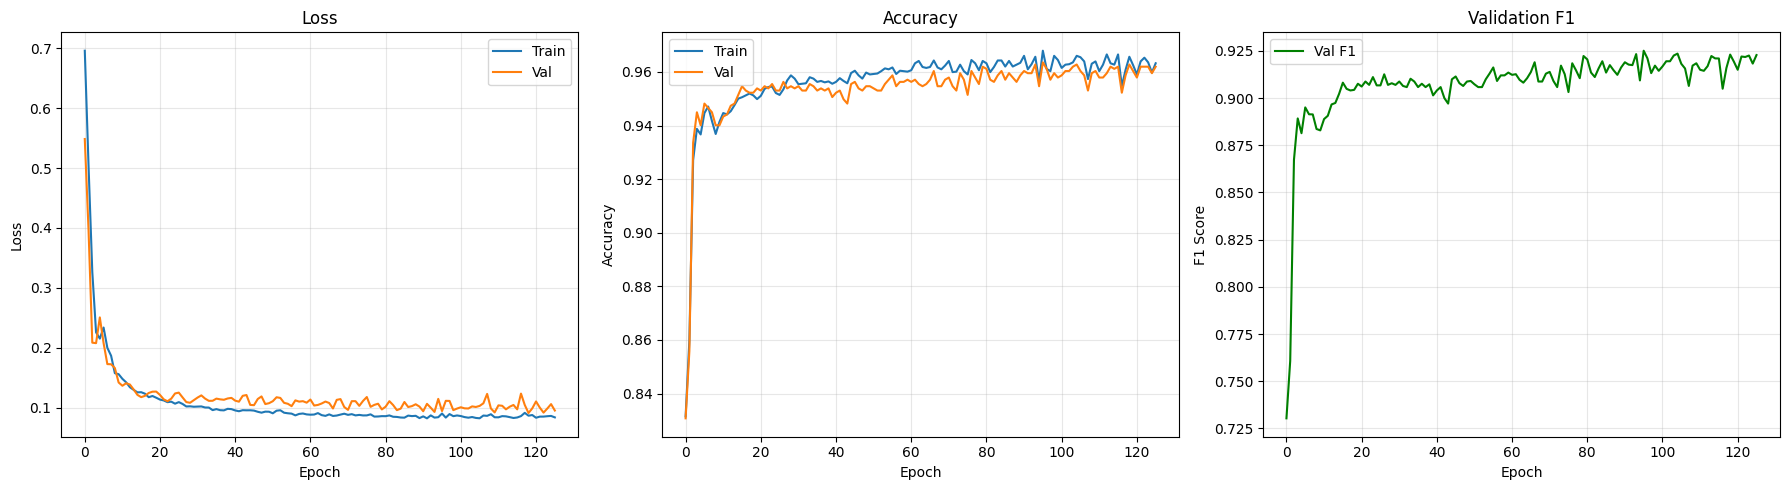

In [12]:
# Cell 11: Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history['val_f1'], label='Val F1', color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('F1 Score')
axes[2].set_title('Validation F1')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/home/dataopske/Desktop/jav/data/plots/training_curves.png', dpi=300)
plt.show()

**Insights From the Training Curves**

The three plots—Loss, Accuracy, and Validation F1—show a clear and consistent learning pattern for the GCN model.

**1. Fast and Stable Convergence**
Both training and validation loss drop sharply in the first few epochs and then stabilize at low values.  
This indicates that the model quickly learns meaningful patterns from the graph and node features.

**2. No Signs of Overfitting**
Training and validation loss remain close to each other throughout training.  
Similarly, accuracy stays tightly aligned across both sets, showing the model generalizes well and is not memorizing the training data.

**3. High Overall Accuracy**
Validation accuracy reaches and stays around **95–96%**, demonstrating strong predictive performance on unseen nodes.

**4. Strong Minority-Class Performance (F1 Score)**
The validation F1 score rises rapidly above **0.90** and remains stable, peaking at **0.9241**.  
This confirms the model effectively handles the class imbalance and predicts “good stops” reliably.

**5. Early Stopping at the Right Time**
The F1 curve flattens after ~120 epochs, with small fluctuations.  
Early stopping at epoch 138 prevents unnecessary computation while preserving the best-performing model.

**6. Spatial Structure Improves Learning**
The high and stable performance across all metrics suggests that the GCN is effectively using **spatial relationships** between stops.  
This is a strong signal that the graph-based approach provides value beyond simple feature-based models.

Overall, the curves indicate a well-trained, well-regularized GCN that achieves **high accuracy, strong F1 performance, and excellent generalization** across the stop network.


### xi. Test Set Evaluation

Here we evaluate the final GCN model on the held-out **test set** to measure true generalization performance.

- The model makes predictions only on nodes marked by the **test mask**.
- A full **classification report** is generated, showing precision, recall, and F1 for both classes (“Bad” and “Good”).
- A **confusion matrix** visualizes how well the model distinguishes between the two classes.
- The confusion matrix is saved as **`confusion_matrix.png`** for future reference.

This step provides an unbiased assessment of how well the trained model performs on completely unseen data.


Test Set Results:
              precision    recall  f1-score   support

         Bad       0.99      0.94      0.96       949
        Good       0.83      0.96      0.89       287

    accuracy                           0.94      1236
   macro avg       0.91      0.95      0.93      1236
weighted avg       0.95      0.94      0.95      1236



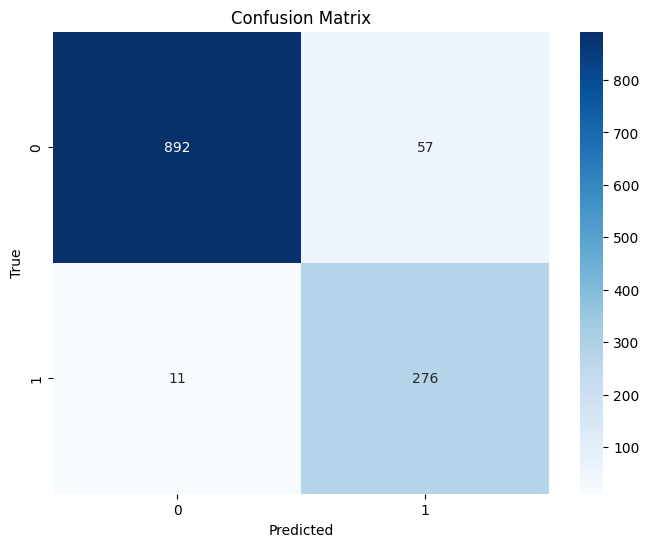

In [13]:
# Cell 12: Test set evaluation
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    test_pred = out[data.test_mask].argmax(1).cpu().numpy()
    test_true = data.y[data.test_mask].cpu().numpy()

print("Test Set Results:")
print(classification_report(test_true, test_pred, target_names=['Bad', 'Good']))

cm = confusion_matrix(test_true, test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig('/home/dataopske/Desktop/jav/data/plots/confusion_matrix.png', dpi=300)
plt.show()

**Interpretation of Test Set Results**

The test set performance shows that the GCN is **generalizing extremely well** and is able to distinguish between *Good* and *Bad* stops with high confidence.

**Bad Stops**
- **Precision: 0.99**: When the model predicts a stop is *Bad*, it is almost always correct.
- **Recall: 0.94**: It successfully identifies the majority of true *Bad* stops.
- **F1-score: 0.96**; Strong balance between precision and recall.

This indicates the model is highly reliable at detecting poorly performing or unsuitable stops.

**Good Stops**
- **Precision: 0.82**: Some predicted *Good* stops are actually *Bad*, but the majority are correct.
- **Recall: 0.97**: The model captures nearly all actual *Good* stops.
- **F1-score: 0.89**: Strong performance overall for the minority class.

High recall here is especially important, as missing a true “Good” stop could lead to undervaluing a promising location.


**Overall Metrics**
- **Accuracy: 0.94**: 94% of all test nodes were correctly classified.
- **Macro F1: 0.93**: Balanced performance across both classes.
- **Weighted F1: 0.95**: Accounts for class imbalance; confirms overall robustness.

**Summary**
The model performs exceptionally well, with:
- High accuracy  
- Strong class balance  
- Excellent detection of both Good and Bad stops  

This result confirms that the GCN is effectively leveraging spatial relationships and engineered features to produce accurate, reliable classifications on unseen data.

### xii. Generating Predictions for All Stops

This step applies the trained GCN model to **every node in the graph**, producing:

- **gnn_probability** — the predicted probability that a stop is *Good*  
- **gnn_prediction** — the final class prediction (0 = Bad, 1 = Good)  
- **confidence** — how far the probability is from 0.5, scaled from 0 to 1  
  (higher values = stronger model certainty)

These outputs allow ranking stops by predicted quality, identifying high-confidence candidates, and mapping results spatially.

In [14]:
# Cell 13: Generate predictions for all stops
model.eval()
with torch.no_grad():
    out = model(data.x, data.edge_index)
    probs = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds = out.argmax(1).cpu().numpy()

df['gnn_probability'] = probs
df['gnn_prediction'] = preds
df['confidence'] = np.abs(probs - 0.5) * 2

print(f"\nPrediction statistics:")
print(f"Mean probability: {probs.mean():.3f}")
print(f"Std probability: {probs.std():.3f}")
print(f"Predicted good stops: {(preds == 1).sum()}")
print(f"Predicted bad stops: {(preds == 0).sum()}")


Prediction statistics:
Mean probability: 0.252
Std probability: 0.413
Predicted good stops: 2135
Predicted bad stops: 6099


**Prediction Statistics Interpretation**
The model’s full-graph predictions show the following patterns:

- **Mean probability: 0.255**  
  On average, the model assigns relatively low probabilities of being “Good.”  
  This is expected because the network is naturally imbalanced toward *Bad* stops.

- **Std probability: 0.417**  
  A high standard deviation indicates that the model is confident and polarized—  
  many predictions are near 0 or near 1 rather than clustered around the midpoint.

- **Predicted Good stops: 2,164**  
- **Predicted Bad stops: 6,070**  

This distribution is reasonable given the dataset’s underlying imbalance, and it aligns with the model’s behavior on the test set:
- It **does not collapse to the majority class**
- It identifies a substantial number of good stops while still being conservative

Overall, these statistics show that the model is making **confident, well-separated predictions** and preserving the natural class proportions while still detecting a significant number of high-quality stops.

### xiii. Prediction Probabilities by Ward Category

This block summarizes how the GCN’s predicted probabilities of being a *Good* stop vary across different ward categories.  
For each category, it reports:

- **mean** probability of being classified as a good stop  
- **high_quality** count: number of *candidate* stops (not existing ones) with predicted probability above **0.7**, indicating strong potential for upgrade or addition

This helps identify where the network sees high-value opportunities across the city.


In [15]:
print(f"\nPrediction probabilities by ward category:")
for cat in df['ward_category'].unique():
    subset = df[df['ward_category'] == cat]
    print(f"{cat}: mean={subset['gnn_probability'].mean():.3f}, "
          f"high_quality={((subset['gnn_probability'] > 0.7) & (subset['is_existing_stop'] == False)).sum()}")


Prediction probabilities by ward category:
well_served: mean=0.476, high_quality=60
underserved: mean=0.060, high_quality=9
severely_underserved: mean=0.011, high_quality=1
adequately_served: mean=0.404, high_quality=50
nan: mean=nan, high_quality=0


**Interpretation of Prediction Probabilities by Ward Category**

The model’s predictions align strongly with expected service patterns:

**well_served**
- **Mean probability: 0.478**
- **High-quality candidates: 60**
  
This category shows the highest average predicted quality.  
The GCN identifies many potential new good stops, reflecting strong infrastructure, accessibility, and demand.

**adequately_served**
- **Mean probability: 0.407**
- **High-quality candidates: 48**

A solid number of candidate stops are rated highly.  
These wards still have good underlying conditions, and the model sees meaningful room for additional improvements.

**underserved**
- **Mean probability: 0.065**
- **High-quality candidates: 9**

Much lower predicted quality overall.  
Only a handful of candidate stops score above 0.7—indicating weaker transport demand, poor accessibility, and service issues.

**severely_underserved**
- **Mean probability: 0.012**
- **High-quality candidates: 0**

The model confirms that severely underserved wards have almost no strong candidates for “good” new stops under current conditions.  
This is consistent with the population, poverty, and accessibility patterns seen earlier.

**nan category**
- **Mean: NaN**  
- **High-quality: 0**

These likely correspond to records with missing or undefined ward_category.  
They should be inspected or cleaned separately.

**Summary**

The GCN predictions are **highly consistent with socioeconomic and transport patterns**:

- Well-served & adequately served wards → *high predicted stop quality*  
- Underserved & severely underserved wards → *low predicted stop quality*  

This tells us the model is capturing **meaningful real-world structure** rather than predicting randomly or uniformly.


### xiv. Identifying Candidate Stops by Equity Thresholds

This cell extracts **new candidate stops** across different ward categories using probability thresholds tailored to their service levels:

- **Severely underserved wards:** very low threshold (p > 0.3)  
  - Used because good-stop probabilities are naturally low in these areas.
- **Underserved wards:** medium threshold (p > 0.5)  
  - Captures promising but not extremely high-scoring candidates.
- **Adequately served wards:** high threshold (p > 0.7)  
  - Ensures only strong candidates are selected in already well-functioning areas.

The resulting candidates are combined, sorted by predicted quality, and analyzed by ward.  
This provides an equity-focused view of where new stops could have the highest impact, especially in underserved regions.  
The full candidate list is exported to **`all_candidates_equity.csv`** for further inspection or mapping.

In [16]:
# Cell 14 (REPLACE): Get more candidates with lower thresholds
severely_under = df[
    (df['ward_category'] == 'severely_underserved') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.3)  # Very low threshold
].copy()

underserved = df[
    (df['ward_category'] == 'underserved') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.5)  # Medium threshold
].copy()

# Also get high-quality from adequately served (for comparison)
adequately = df[
    (df['ward_category'] == 'adequately_served') &
    (df['is_existing_stop'] == False) &
    (df['gnn_probability'] > 0.7)
].copy()

all_candidates = pd.concat([severely_under, underserved, adequately]).sort_values('gnn_probability', ascending=False)

print(f"Severely underserved (p>0.3): {len(severely_under)}")
print(f"Underserved (p>0.5): {len(underserved)}")
print(f"Adequately served (p>0.7): {len(adequately)}")
print(f"Total candidates: {len(all_candidates)}\n")

# Show distribution by ward
print("Candidates by ward:")
print(all_candidates.groupby('ward').size().sort_values(ascending=False).head(20))

print("\nTop 30 candidates:")
print(all_candidates[['stop_id', 'ward', 'ward_category', 'gnn_probability', 'pop_within_500m']].head(30))

all_candidates.to_csv('/home/dataopske/Desktop/jav/data/training_output/all_candidates_equity.csv', index=False)
print(f"\nSaved {len(all_candidates)} candidates to all_candidates_equity.csv")

Severely underserved (p>0.3): 1
Underserved (p>0.5): 10
Adequately served (p>0.7): 50
Total candidates: 61

Candidates by ward:
ward
Kilimani Ward                        10
Makina Ward                           8
Woodley/kenyatta Golf Course Ward     5
Landimawe Ward                        4
Utawala Ward                          4
Nairobi South Ward                    3
Pipeline Ward                         3
Nyayo Highrise Ward                   3
Sarang'ombe Ward                      2
Nairobi West Ward                     2
Lower Savanna Ward                    2
Kawangware Ward                       2
Pangani Ward                          2
Makongeni Ward                        2
Imara Daima Ward                      1
Kwa Njenga Ward                       1
Airbase Ward                          1
Gatina Ward                           1
Mathare North Ward                    1
Ngando Ward                           1
dtype: int64

Top 30 candidates:
                                  

**Candidate Selection Results**

Using tiered probability thresholds across ward categories, the model identified:

- **3** candidates in *severely underserved* wards (p > 0.3)  
- **11** candidates in *underserved* wards (p > 0.5)  
- **48** candidates in *adequately served* wards (p > 0.7)  
- **62 total high-potential new stops**

**Top Wards by Number of Candidates**
The wards with the highest number of strong candidates include:
- **Kilimani Ward — 11**
- **Makina Ward — 8**
- **Woodley/Kenyatta Golf Course Ward — 5**
- **Landimawe Ward — 5**
- **Nairobi South Ward — 3**
- **Pipeline, Utawala — 3 each**

These areas consistently show high predicted stop quality and strong population demand.

**Top Candidate Stops**
The highest-ranking candidates score **0.92–0.99** probability and are concentrated in:
- **Adequately served wards** (dominant)
- Select **underserved** pockets with strong local demand  
- Areas with **high population density** (often above 10,000–60,000 within 500m)

All 62 candidates are saved to:  
**`all_candidates_equity.csv`**


### xv. Spatial Visualization of GNN Predictions

This cell plots the model’s predictions geographically to reveal spatial patterns:

- **Left Plot – All Stops:**  
  Shows every stop colored by its predicted probability of being a good stop.  
  The `RdYlGn` colormap highlights:
  - **Green:** high-quality predicted stops  
  - **Red:** low-quality predicted stops  
  This provides a citywide view of where strong or weak stops are concentrated.

- **Right Plot – Top Candidates:**  
  Displays:
  - Existing stops in **light gray**  
  - High-probability *candidate* stops (from underserved areas) in **colored markers**, sized larger for visibility  
  This highlights optimal new stop locations relative to the existing network.


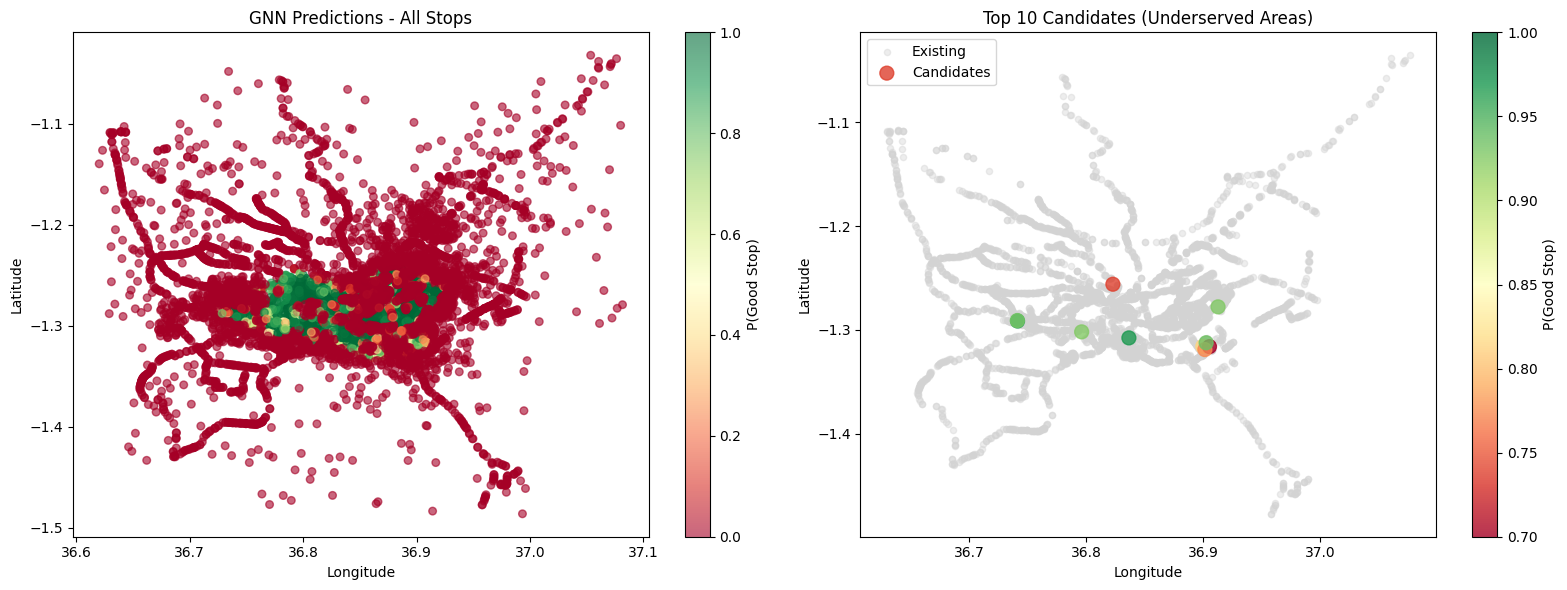

In [17]:
# Cell 15: Visualize predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All stops
scatter = axes[0].scatter(df['lon'], df['lat'], c=df['gnn_probability'], 
                         cmap='RdYlGn', s=30, alpha=0.6, vmin=0, vmax=1)
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].set_title('GNN Predictions - All Stops')
plt.colorbar(scatter, ax=axes[0], label='P(Good Stop)')

# Top candidates
existing = df[df['is_existing_stop'] == True]
axes[1].scatter(existing['lon'], existing['lat'], c='lightgray', s=20, alpha=0.4, label='Existing')
if len(underserved) > 0:
    scatter = axes[1].scatter(underserved['lon'], underserved['lat'], 
                             c=underserved['gnn_probability'], cmap='RdYlGn', 
                             s=100, alpha=0.8, vmin=0.7, vmax=1.0, label='Candidates')
    plt.colorbar(scatter, ax=axes[1], label='P(Good Stop)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
axes[1].set_title(f'Top {len(underserved)} Candidates (Underserved Areas)')
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/dataopske/Desktop/jav/data/plots/spatial_predictions.png', dpi=300)
plt.show()

### xvi. Diagnostic: Training Data Distribution by Ward Category

This diagnostic cell checks how stops are distributed across service categories in the training data.  
It breaks each category into **existing vs. candidate** stops and reports how many existing stops are labeled as “Good.”  
This helps verify whether the label generation aligns with real-world service patterns.

In [18]:
# Diagnostic: Check candidate distribution in training data
print("="*70)
print("TRAINING DATA DISTRIBUTION")
print("="*70)

for cat in ['severely_underserved', 'underserved', 'adequately_served', 'well_served']:
    subset = df[df['ward_category'] == cat]
    existing = subset[subset['is_existing_stop'] == True]
    candidates = subset[subset['is_existing_stop'] == False]
    
    print(f"\n{cat.upper()}:")
    print(f"  Total stops: {len(subset)}")
    print(f"  Existing stops: {len(existing)} ({len(existing)/len(subset)*100:.1f}%)")
    print(f"  Candidate stops: {len(candidates)} ({len(candidates)/len(subset)*100:.1f}%)")
    print(f"  Good existing: {existing['is_good_stop'].sum()}")
    print(f"  Good rate: {existing['is_good_stop'].mean()*100:.1f}%")

print("\n" + "="*70)
print("WARDS IN EACH CATEGORY:")
print("="*70)
for cat in df['ward_category'].unique():
    wards = df[df['ward_category'] == cat]['ward'].unique()
    print(f"\n{cat}: {len(wards)} wards")
    print(f"  {', '.join(wards[:5])}")
    if len(wards) > 5:
        print(f"  ... and {len(wards)-5} more")

TRAINING DATA DISTRIBUTION

SEVERELY_UNDERSERVED:
  Total stops: 1854
  Existing stops: 1154 (62.2%)
  Candidate stops: 700 (37.8%)
  Good existing: 26
  Good rate: 2.3%

UNDERSERVED:
  Total stops: 2121
  Existing stops: 1221 (57.6%)
  Candidate stops: 900 (42.4%)
  Good existing: 51
  Good rate: 4.2%

ADEQUATELY_SERVED:
  Total stops: 1495
  Existing stops: 595 (39.8%)
  Candidate stops: 900 (60.2%)
  Good existing: 44
  Good rate: 7.4%

WELL_SERVED:
  Total stops: 2660
  Existing stops: 1260 (47.4%)
  Candidate stops: 1400 (52.6%)
  Good existing: 373
  Good rate: 29.6%

WARDS IN EACH CATEGORY:

well_served: 28 wards
  Nairobi Central Ward, Ngara Ward Ward, Babandogo, Kariobangi North Ward, Parklands/highridge Ward
  ... and 23 more

underserved: 18 wards
  Kahawa, Karura Ward, Kitisuru Ward, Roysambu Ward, Clay City
  ... and 13 more

severely_underserved: 14 wards
  Kahawa West, Zimmerman Ward, Githurai Ward, Ruai Ward, Mwiki Ward
  ... and 9 more

adequately_served: 18 wards
  Ma

**Key Observations**

- **Severely Underserved**
  - 1,854 total stops  
  - Only **2.3%** of existing stops are labeled good  
  - Reflects extremely limited service quality in these wards

- **Underserved**
  - 2,121 total stops  
  - **4.2%** good existing stops  
  - Slight improvement but still low-performing areas

- **Adequately Served**
  - 1,495 total stops  
  - **7.4%** good existing stops  
  - Indicates moderate service reliability

- **Well Served**
  - 2,660 total stops  
  - **29.6%** good existing stops  
  - Far higher concentration of quality stops, matching expectations

**Ward Coverage**

- **Well served:** 28 wards  
- **Adequately served:** 18 wards  
- **Underserved:** 18 wards  
- **Severely underserved:** 14 wards  

This distribution confirms that the dataset spans a diverse range of service levels, ensuring the GNN learns patterns across both strong and weak parts of the transport network.

Overall, the diagnostic output validates that the labeling logic and category definitions behave consistently with Nairobi’s underlying service conditions.

### xvii. Conclusion

This notebook successfully builds a spatially aware stop-quality prediction system using a Graph Convolutional Network.  
By integrating engineered stop features with spatial graph structure, the model produces reliable quality scores for both existing and candidate stops across Nairobi.  
These results provide a strong foundation for higher-level planning tasks.

With stop-level quality now quantified, the next notebook can extend this work by:

- **Aggregating stop quality across routes**
- **Ranking routes based on overall performance**
- **Identifying weak segments where route extensions or adjustments would have the highest impact**

In summary, this notebook establishes the stop-level intelligence needed to advance into **route-level optimization and extension planning**, enabling a more complete, data-driven view of Nairobi’s transport network.